$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.7


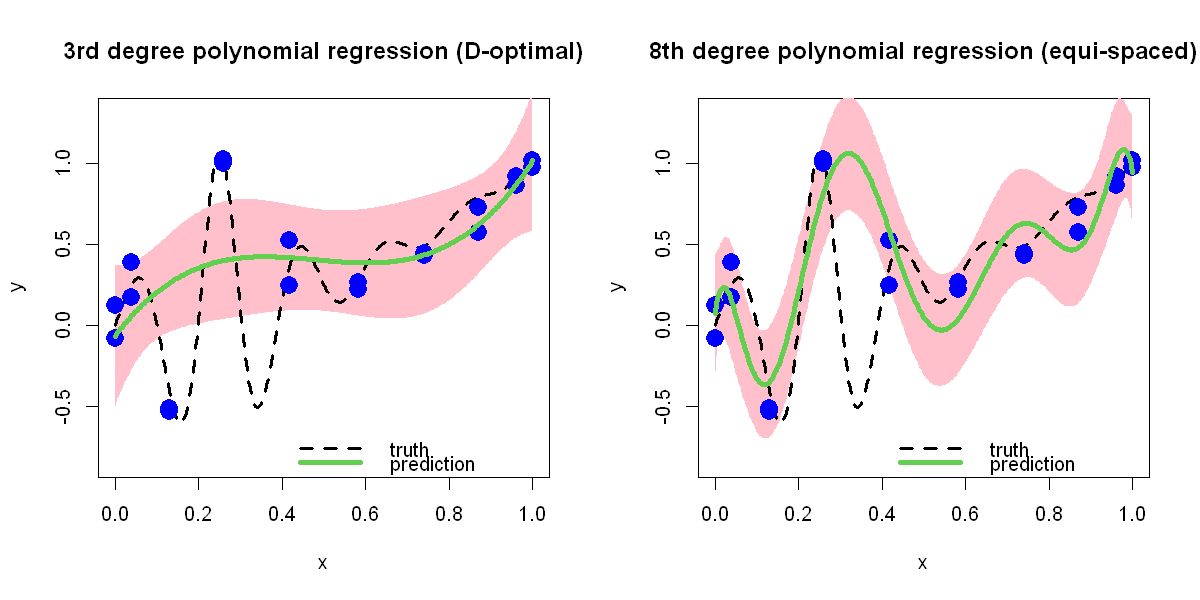

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

再次考虑 $$h(x)=\frac{\sin(10\pi x)}{1+64(x-.25)}+x^{2},x\in[0,1],$$ 但本次使用试验设计方法来优化线性回归的拟合效果.若需要 10 个互不相同的测点,则可取多项式阶数 $m=9$.为构造候选集,首先在区间 $[0,1]$ 内选取 301 个等间距点,再构造向量 $\boldsymbol{c}_{j}=(1,c_{j},\dots,c_{j}^{9})$,$j=1,\dots,301$.随后调用程序包 `AlgDesign` 中的 `optFederov` 函数求解 D 最优设计,所得测点绘制于图 2.7.可以观察到,最优测点向区间两端边界聚集.两组多项式拟合效果相比之前均有所提升,尤其是八次多项式在边界附近剧烈震荡的现象完全消失.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建宽 10 英寸,高 5 英寸的画布,将画布分为 1x2:

```r
options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))
```

定义函数 $f(x)=\frac{\sin(10\pi x)}{1+64(x-.25)}+x^{2}$.选取 $[0,1]$ 上的 301 个点组成向量 `test`,分别计算其对应的函数值,组成向量 `true`.将 `test` 的范围从 $[0,1]$ 放缩至 $[-1,1]$,向量命名为 `tests`.使用 R 包 `AlgDesign` 中的 `optFederov` 函数,通过实验设计选取观察点,其中公式为背景信息中的 9 次多项式,实验次数为 `n`,候选集为 `tests`,要求精确设计(即给出每个点实验次数的具体次数而不是概率),返回列表命名为 `a`.取其 `design` 数据框中的第一列为最终选取的 10 个观察点.重复选 2 次,范围还原回 $[0,1]$ 组成向量 `D`.设置随机种子为 `5`,利用均值为 `20`,方差为 `.1` 的正态分布随机生成 20 个误差数据组成向量 `e`.加到 `f(x)` 上组成带有噪声的函数值,组成向量 `y`:

```r
x=seq(0,1,length=301)
f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
r=2
tests=2*test-1
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=tests,approximate=FALSE)
D=rep(c(a$design[,1]),r)
D=(D+1)/2
set.seed(5)
e=rnorm(n*r,sd=.1)
y=f(D)+e
```

为了方便线性回归,将 `D` 的范围从 $[0,1]$ 放缩至 $[-1,1]$,向量命名为 `d`.进行 3 次线性回归,返回的 `lm` 类对象命名为 `a`.对 `tests` 中的每个点都进行预测,返回预测值,上下界,其组成的矩阵命名为 `pred`.开始作图:创建空白图像,其中 $x$ 轴标签为 `x`,$y$ 轴标签为 `y`,$y$ 轴显示范围为 $[\min(f(x))-.25,\max(f(x))+.25]$,主标题为 `3rd degree polynomial regression (equi-spaced)`.叠加预测区间,其中颜色为粉色,不显示边界.叠加真实函数曲线,其中曲线类型为虚线,线宽为 3.叠加观测点,其中点的类型为实心圆点,放缩系数为 2,颜色为蓝色.叠加预测曲线,其中颜色为绿色,线宽为 4.添加图例,其中内容为 `truth` 和 `prediction` 以及其对应的曲线类型,颜色,线宽,图例不显示边框:

```r
d=2*D-1
i=3
a=lm(y~poly(d,i))
pred=predict(a,newdata=data.frame(d=tests),interval="confidence")
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="3rd degree polynomial regression (equi-spaced)")
polygon(c(test,rev(test)),c(pred[,2],rev(pred[,3])),col="pink",border=NA)
lines(test,f(test),lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred[,1],col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")
```

再进行 8 次线性回归,其余设置同 3 次回归:

```r
i=8
a=lm(y~poly(d,i))
pred=predict(a,newdata=data.frame(d=tests),interval="confidence")
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="8th degree polynomial regression (equi-spaced)")
polygon(c(test,rev(test)),c(pred[,2],rev(pred[,3])),col="pink",border=NA)
lines(test,f(test),lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred[,1],col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")
```

将画布还原回 1x1:

```r
par(mfrow=c(1,1))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

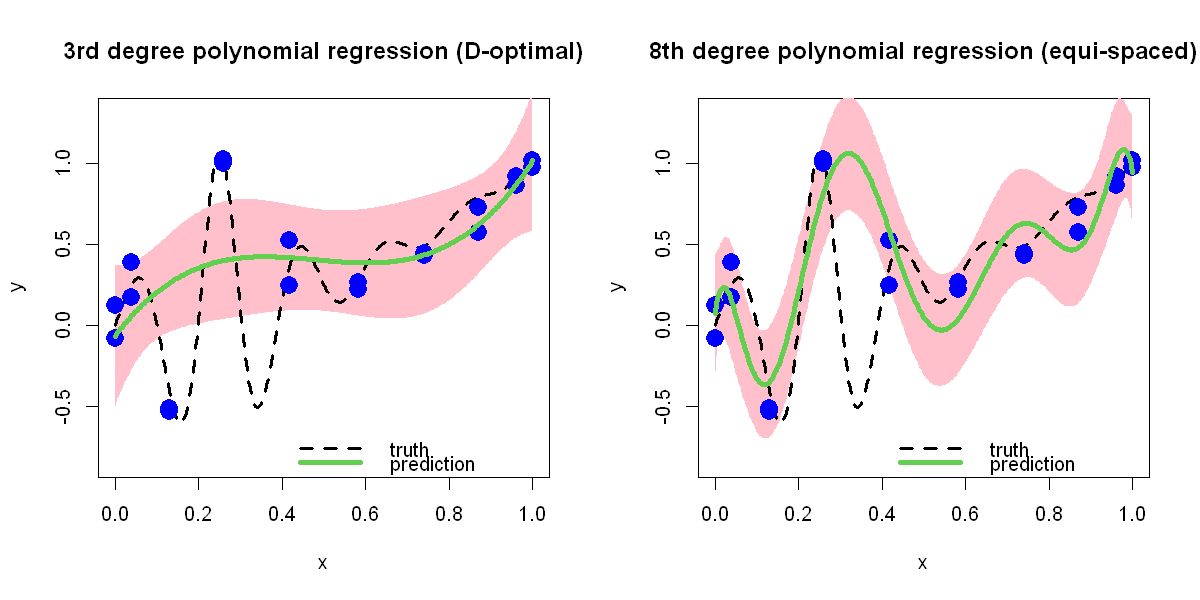

In [1]:
# 图 2.7

options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))

x=seq(0,1,length=301)
f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
r=2
tests=2*test-1
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=tests,approximate=FALSE)
D=rep(c(a$design[,1]),r)
D=(D+1)/2
set.seed(5)
e=rnorm(n*r,sd=.1)
y=f(D)+e

## 3 次线性回归

d=2*D-1
i=3
a=lm(y~poly(d,i))
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="3rd degree polynomial regression (D-optimal)")
pred=predict(a,newdata=data.frame(d=tests),interval="confidence")
polygon(c(test,rev(test)),c(pred[,2],rev(pred[,3])),col="pink",border=NA)
lines(test,f(test),lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred[,1],col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")

## 8 次线性回归

i=8
a=lm(y~poly(d,i))
pred=predict(a,newdata=data.frame(d=tests),interval="confidence")
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="8th degree polynomial regression (equi-spaced)")
polygon(c(test,rev(test)),c(pred[,2],rev(pred[,3])),col="pink",border=NA)
lines(test,f(test),lty=2,lwd=3)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred[,1],col=3,lwd=4)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n")

par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$